In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import colorcet as cc
import warnings
import re

from norm import cut_norm,interpolate_and_sample

def readsheet(sheetname,excel_file_path):
    data = pd.read_excel(excel_file_path,sheet_name=sheetname)
    columns_to_remove = ['Temp. [°C]']
    data.drop(columns=columns_to_remove, inplace=True)
    return data

In [2]:
#SUM ALL THE DATA
excel_file_path = 'WT_in_LB_data_Omar_s1.XLSX'
lsheetnames = ['P0002','P0005','P0008','P0012','P0030']
numbers=[0,1,2,3,4]
excel_file_path2 = 'different_conditions_data_Omar_s2.XLSX'
lsheetnames2 = ['P12_WT','P13_TolC_KO','P16_AcrD_KO','P17_AcrA_KO','P18_AcrB_KO','P24_AcrBD_KO']
numbers2=[0,1,2,3,4,5]
split = [n.split('_') for n in lsheetnames2]
gene= [sublist[1] for sublist in split]         #The strain: WT,AcrA,AcrB,etc...
custom_palette=sns.color_palette(cc.glasbey) 
lsheetnames3 = ['P25_kan_2_50','P27_kan_1_25','P28_kan','P30_kan_2_50']
numbers3=[0,1,2,3]

legend_added = set()  # To keep track of colors for which legend entry is added
time_to_cut=175000
nvalues_to_interpolate=299
sum_data=pd.DataFrame()
sum_data2=pd.DataFrame()
sum_data3=pd.DataFrame()
batches=[]
batch_color_map = {}
color_index = 0
experiments=[]               

# Suppress PerformanceWarning from pandas
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

for sheetname,i in zip(lsheetnames,numbers):
    df = readsheet(sheetname, excel_file_path)
    df=cut_norm(df,time_to_cut)
    df = interpolate_and_sample(df,time_to_cut,nvalues_to_interpolate)
    Time=df['Time [s]'].values
    for column,j in zip(df.columns.values[2:],enumerate(df.columns.values[2:])):
        new_column_name = f'WT_LB_{i}_{j[0]}'
        sum_data[new_column_name]=df[column]
        batch=f'WT_LB_{i}'
        batches.append(batch)
        for batch_ in batches:
            if batch_ not in batch_color_map:
                batch_color_map[batch_] = custom_palette[color_index]
                color_index = (color_index + 1) % len(custom_palette)
        color = batch_color_map[batch]
        # Add legend entry only if the color is not yet added to the legend
        if color not in legend_added:
            legend_added.add(color)  
            experiments.append(batch)

for sheetname2,i in zip(lsheetnames2,numbers2):
    df = readsheet(sheetname2,excel_file_path2)
    df=cut_norm(df,time_to_cut)
    df = interpolate_and_sample(df,time_to_cut,nvalues_to_interpolate)
    split_column_names = [name.split('_') for name in df.columns.values[2:]]
    drugs=[sublist[0] for sublist in split_column_names]
    plate_indexes=[sublist[1] for sublist in split_column_names]
    sum_split=[name.split('_') for name in sum_data.columns]
    joined_sum_split = ['_'.join(parts[:3]) for parts in sum_split]
    for column,drug,plate_index in zip(df.columns.values[2:],drugs,plate_indexes):
        aux=0
        for j in range (len(joined_sum_split)):
            if joined_sum_split[j]==f'{gene[i]}_{drug}_{aux}':
                aux+=1    
        new_column_name = f'{gene[i]}_{drug}_{aux}_{plate_index}'
        sum_data2[new_column_name]=df[column]
        batch=f'{gene[i]}_{drug}_{aux}'
        batches.append(batch)
        for batch_ in batches:
            if batch_ not in batch_color_map:
                batch_color_map[batch_] = custom_palette[color_index]
                color_index = (color_index + 1) % len(custom_palette)
        color = batch_color_map[batch]
        if color not in legend_added:
            legend_added.add(color)  
            experiments.append(batch)

for sheetname3 in lsheetnames3:
    df = readsheet(sheetname3,excel_file_path2)
    df=cut_norm(df,time_to_cut)
    df = interpolate_and_sample(df,time_to_cut,nvalues_to_interpolate)
    split_column_names = [name.split('_') for name in df.columns.values[2:]]
    strain_drugs=['_'.join(parts[:2]) for parts in split_column_names]
    plate_indexes=[sublist[2] for sublist in split_column_names]
    sum_split=[name.split('_') for name in sum_data.columns]
    joined_sum_split = ['_'.join(parts[:3]) for parts in sum_split]
    sum_split2=[name.split('_') for name in sum_data2.columns]
    joined_sum_split2 = ['_'.join(parts2[:3]) for parts2 in sum_split2]
    sum_split3=[name.split('_') for name in sum_data3.columns]
    joined_sum_split3 = ['_'.join(parts[:3]) for parts in sum_split3]
    for column,strain_drug,plate_index in zip(df.columns.values[2:],strain_drugs,plate_indexes):
        aux=0
        for j in range (len(joined_sum_split)):
            if joined_sum_split[j]==f'{strain_drug}_{aux}':
                aux+=1   
        for k in range (len(joined_sum_split2)):
            if joined_sum_split2[k]==f'{strain_drug}_{aux}':
                aux+=1 
        for l in range (len(joined_sum_split3)):
            if joined_sum_split3[l]==f'{strain_drug}_{aux}':
                aux+=1       
        new_column_name = f'{strain_drug}_{aux}_{plate_index}'
        sum_data3[new_column_name]=df[column]
        batch=f'{strain_drug}_{aux}'
        batches.append(batch)
        for batch in batches:
            if batch not in batch_color_map:
                batch_color_map[batch] = custom_palette[color_index]
                color_index = (color_index + 1) % len(custom_palette)
        color = batch_color_map[batch]
        if color not in legend_added:
            legend_added.add(color)  
            experiments.append(batch)

total_data = pd.concat([sum_data, sum_data2,sum_data3], axis=1)

In [3]:
# Function to extract numbers for K and M
def extract_k_m(s):
    # Use regular expressions to find 'K' followed by a number and 'M' followed by a number
    k_match = re.search(r'K(\d+(\.\d+)?)', s)  # Matches 'K' followed by a number
    m_match = re.search(r'M(\d+(\.\d+)?)', s)  # Matches 'M' followed by a number
    
    # Extract the matched numbers, or 0 if not found
    k_value = float(k_match.group(1)) if k_match else 0
    m_value = float(m_match.group(1)) if m_match else 0
    
    return [k_value, m_value]

# Function to create a binary array for presence of each target
def binary_presence(s):
    # Target elements to check
    strain_types = ['WT', 'TolC', 'AcrD', 'AcrA', 'AcrB', 'AcrBD', 'AcrE', 'AcrF']
    return [1 if target == s else 0 for target in strain_types]


In [4]:
#Reorder the data by drugs/strains
train_data=pd.DataFrame()
test_data=pd.DataFrame()
drug_conditions_test=pd.DataFrame()
strain_conditions_test=pd.DataFrame()
drug_conditions_train=pd.DataFrame()
strain_conditions_train=pd.DataFrame()
batches_test=[]
batches_train=[]
np.random.seed(4)

columns=total_data.columns[:]
num_list = list(range(len(batches)))

experiments2=[]
split_experiments=[name.split('_') for name in experiments]
exp=1       #[1] for drugs, [0] for strain
experimentos=[sublist[exp] for sublist in split_experiments]
batches2=[]
parts=[name.split('_') for name in batches]
batches2=[sublist[exp] for sublist in parts]      
print(len(batches2))

for experimento in experimentos:
    if experimento not in experiments2:
        experiments2.append(experimento)

print(len(experiments2),experiments2)

#Select the test_data and the train_data, 15% splitting
for experiment in experiments2:
    columns_to_select=[]
    for batch,i in zip(batches2,num_list):
        if batch==experiment:
            columns_to_select.append(columns[i])
    #print(experiment,len(columns_to_select))              
    num_columns_to_select = int(len(columns_to_select) * 0.15)        
    test_columns = np.random.choice(columns_to_select, num_columns_to_select,replace=False)
    batches_test.extend([experiment] * len(test_columns))
    test_columns_data = total_data[test_columns]
    test_data = pd.concat([test_data, test_columns_data], axis=1)

    #Get the test conditions vectors (for drugs and strains)
    split_test_columns=[name.split('_') for name in test_columns]
    raw_strains=[sublist[0] for sublist in split_test_columns]
    raw_drugs=[sublist[1] for sublist in split_test_columns]
    strain_vector = [binary_presence(item) for item in raw_strains]
    drug_vector = [extract_k_m(item) for item in raw_drugs]
    df= pd.DataFrame(strain_vector)
    df2= pd.DataFrame(drug_vector)
    strain_conditions_test = pd.concat([strain_conditions_test, df], axis=0)
    drug_conditions_test = pd.concat([drug_conditions_test, df2], axis=0)

    train_columns = [col for col in columns_to_select if col not in test_columns]
    print(len(test_columns),len(columns_to_select),num_columns_to_select,len(train_columns)+len(test_columns))
    train_columns_data = total_data[train_columns]
    train_data = pd.concat([train_data, train_columns_data], axis=1)
    batches_train.extend([experiment] * len(train_columns))

    #Get the train conditions vectors (for drugs and strains)
    split_train_columns=[name.split('_') for name in train_columns]
    raw_strains=[sublist[0] for sublist in split_train_columns]
    raw_drugs=[sublist[1] for sublist in split_train_columns]
    strain_vector = [binary_presence(item) for item in raw_strains]
    drug_vector = [extract_k_m(item) for item in raw_drugs]
    df= pd.DataFrame(strain_vector)
    df2= pd.DataFrame(drug_vector)
    strain_conditions_train = pd.concat([strain_conditions_train, df], axis=0)
    drug_conditions_train = pd.concat([drug_conditions_train, df2], axis=0)

#print(test_data.shape,train_data.shape)
print('The number of total growth curves is:',len(batches_test),len(batches_train))         

train_data_T=train_data.T
test_data_T=test_data.T
X_train3=train_data_T.values
X_test3=test_data_T.values
X_train_tensor3 = torch.FloatTensor(X_train3)
X_test_tensor3 = torch.FloatTensor(X_test3)
C_test_tensor = torch.FloatTensor(pd.concat([strain_conditions_test, drug_conditions_test], axis=1).values)        #Conditions tensor (strain+drug vectors), to introduce it as input to the CVAE
C_train_tensor = torch.FloatTensor(pd.concat([strain_conditions_train, drug_conditions_train], axis=1).values)

print(test_data_T.shape,strain_conditions_test.shape,drug_conditions_test.shape,train_data_T.shape,strain_conditions_train.shape,drug_conditions_train.shape,C_test_tensor.shape)
custom_palette=sns.color_palette(cc.glasbey,len(batches_test)) 

816
16 ['LB', 'K1.25', 'K2.50', 'K3.75', 'M0.25', 'M0.50', 'M1.00', 'K1.25&M0.25', 'K1.25&M0.50', 'K1.25&M1.00', 'K2.50&M0.25', 'K2.50&M0.50', 'K2.50&M1.00', 'K3.75&M0.25', 'K3.75&M0.50', 'K3.75&M1.00']
29 195 29 195
14 98 14 98
22 149 22 149
6 44 6 44
4 32 4 32
4 32 4 32
4 32 4 32
3 26 3 26
3 26 3 26
3 26 3 26
3 26 3 26
3 26 3 26
3 26 3 26
3 26 3 26
3 26 3 26
3 26 3 26
The number of total growth curves is: 110 706
(110, 100) (110, 8) (110, 2) (706, 100) (706, 8) (706, 2) torch.Size([110, 10])


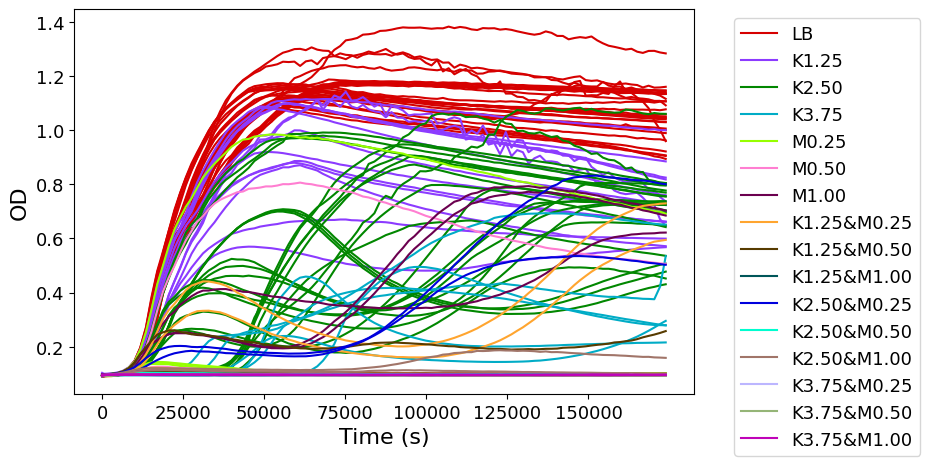

In [5]:
fig, ax = plt.subplots(1,1,figsize=[8,5])
custom_palette=sns.color_palette(cc.glasbey,len(experiments2)) 

total_data['Time [s]'] = Time
test_data['Time [s]'] = Time
train_data['Time [s]'] = Time
legend_added = set()  
batch_color_map = {}
color_index = 0
for batch in batches2:
    if batch not in batch_color_map:
        batch_color_map[batch] = custom_palette[color_index]
        color_index = (color_index + 1) % len(custom_palette)

for column,batch in zip(test_data.columns.values[:len(batches_test)],batches_test):
    color = batch_color_map[batch]
    if color not in legend_added:
        sns.lineplot(data=test_data, x=test_data['Time [s]'], y=column,ax=ax,color=color,label=batch)
        legend_added.add(color)  # Add the color to the set to indicate the legend entry is added
    else:
        sns.lineplot(data=test_data, x=test_data['Time [s]'], y=column,ax=ax,color=color)

# for column,batch in zip(total_data.columns.values[:len(batches2)],batches2):
#     color = batch_color_map[batch]
#     if(batch=='K1.25'):
#         if color not in legend_added:
#             sns.lineplot(data=total_data, x=total_data['Time [s]'], y=column,ax=ax,color=color,label=batch)
#             legend_added.add(color)  # Add the color to the set to indicate the legend entry is added
#         else:
#             sns.lineplot(data=total_data, x=total_data['Time [s]'], y=column,ax=ax,color=color)

plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('OD', fontsize=16)
ax.set_xticks(range(0, 175000, 25000))
ax.tick_params(axis='both', which='major', labelsize=13)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 13})
#plt.tight_layout()  # Adjust layout to make room for the legend
plt.show()


In [6]:
class DecoderNN2(nn.Module):
    def __init__(self, output_dim, condition_dim, num_hidden_layers, hidden_dims):
        super(DecoderNN2, self).__init__()
        
        # Construct the decoder
        decoder_layers = []
        prev_dim = condition_dim + 2    # Adjusted input dimension as the condition dimension + 2 (the point_2D)
        for i in reversed(range(num_hidden_layers)):
            decoder_layers.append(nn.Linear(prev_dim, hidden_dims[i]))
            decoder_layers.append(nn.Sigmoid())
            prev_dim = hidden_dims[i]
        
        decoder_layers.append(nn.Linear(hidden_dims[0], output_dim))
        
        self.decoder = nn.Sequential(*decoder_layers)

    def forward(self, c):
        num_points=c.shape[0]                 # The amount of samples introduced to the NN
        mean = torch.zeros(num_points, 2)     # Shape (num_points, 2) for 2D mean
        logvar = torch.zeros(num_points, 2)   # Shape (num_points, 2) for 2D log-variance
        
        # Sample noise for each 2D point
        epsilon = torch.randn_like(logvar)    # Shape (num_points, 2) with normal samples
        points_2D = mean + torch.exp(logvar * 0.5) * epsilon  # Shape (num_points, 2)

        x = torch.cat([c,points_2D], dim=1)
        #print(x.shape)
        x_hat = self.decoder(x)

        return x_hat    

def loss_function(x, x_hat):
    reproduction_loss =nn.MSELoss()(x,x_hat)
    return reproduction_loss

In [7]:
torch.manual_seed(42)
trained_models = []

output_dim = X_train3.shape[1]  # Number of input features
condition_dim= 8+2 # Strain and drug dimension vectors
num_hidden_layers=3
hidden_layers=[64,32,16]      #From bigger to smaller
model = DecoderNN2(output_dim, condition_dim, num_hidden_layers, hidden_layers)
alpha=5E-5  #5E-5
str_alpha="{:.0E}".format(alpha)

# Loss function and optimizer
optimizer = optim.Adam(model.parameters(), lr=5E-3)     #Optimizer algorithm, lr: learning rate

# Training the autoencoder
num_epochs = 10000          #Number of 'jumps'
train_losses = []
test_losses = []

for epoch in range(num_epochs):
   # Training phase
   x_hat = model(C_train_tensor)            # Forward pass
   train_loss = loss_function(X_train_tensor3, x_hat)

   # Backward pass and optimization, in fact this is the training of the parameters of the model
   optimizer.zero_grad()         #In this way the gradient is not cumulative
   train_loss.backward()             #The gradients(derivatives) of the parameters to optimize(points of the growth ) 
   optimizer.step()              #Actualize the optimizer(do the step of the optimizer), in the case of the Adam it multiplies the new vector by the lr

   train_losses.append(train_loss.item())  # Append train loss
   
   with torch.no_grad():  # Disable gradient calculation for the test evaluation
      x_hat = model(C_test_tensor)            # Forward pass
      test_loss = loss_function(X_test_tensor3, x_hat)
   print(test_loss.detach().numpy())
   test_losses.append(test_loss.item())  # Append test loss
trained_models.append(model)
#torch.save(model.state_dict(), 'saved_models/VAE_n1000_alpha{str_alpha[0]}E{str_alpha[4]}lr5E4_v3.pth')
print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

0.35725367
0.2603161
0.20418918
0.17507213
0.16196138
0.15739651
0.15660319
0.1570034
0.15736218
0.15735622
0.15707685
0.15656711
0.1561264
0.15570064
0.15547715
0.15529342
0.1549778
0.15460032
0.1540006
0.15306504
0.15220854
0.15099889
0.14971614
0.14866522
0.14747073
0.14643972
0.1456242
0.14485283
0.1441502
0.14363645
0.14289668
0.14246951
0.14210296
0.14157487
0.14100386
0.14067152
0.13966998
0.13943978
0.13891786
0.13833253
0.1375381
0.1369223
0.13639076
0.13591269
0.13450617
0.13339096
0.13286856
0.13198085
0.13057971
0.1297219
0.12799801
0.12709954
0.12449614
0.12402671
0.12240197
0.120734654
0.11922315
0.11706746
0.11497738
0.11287926
0.110409856
0.10823433
0.105630115
0.103463426
0.10168062
0.098241724
0.09488897
0.09485387
0.09157314
0.088852026
0.0870609
0.08393216
0.08254015
0.08152768
0.0788455
0.07735712
0.07663205
0.07587056
0.07450681
0.07389959
0.07304859
0.07256886
0.072051734
0.07174544
0.07180533
0.07082338
0.07014949
0.06987155
0.069961384
0.06948404
0.06851768
0.0

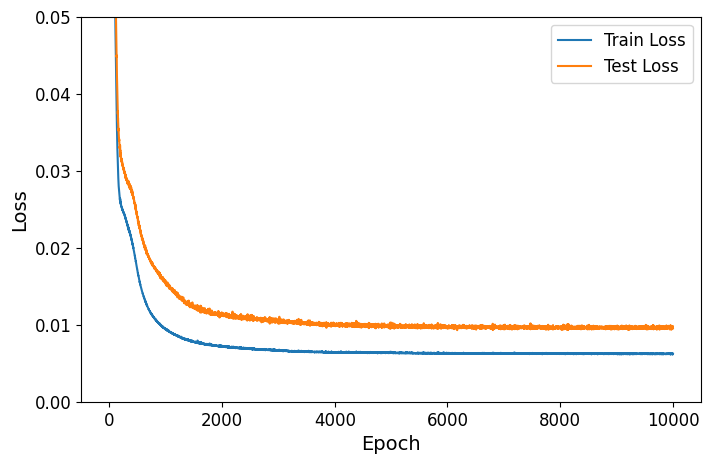

In [8]:
fig, ax = plt.subplots(1,1,figsize=[8,5])
#plt.title('Train and Test Loss over Epochs')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
epochs = range(1, num_epochs + 1)

sns.lineplot(x=epochs, y=train_losses, label='Train Loss',ax=ax)
sns.lineplot(x=epochs, y=test_losses, label='Test Loss',ax=ax)
ax.set_ylim(0, 0.05)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(fontsize=12)

110 (100, 111)


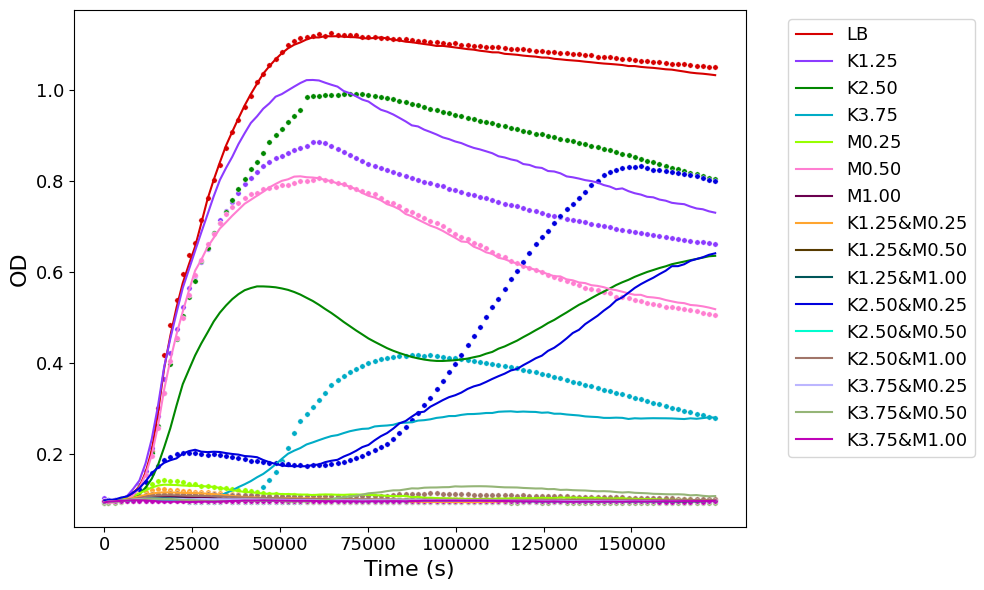

In [9]:
#Plotting the decoded vectors
fig, ax = plt.subplots(1,1,figsize=[10,6])
custom_palette=sns.color_palette(cc.glasbey,len(experiments2))

model=trained_models[0]
print(len(batches_test),test_data.shape)        
columns2=test_data.columns[:len(batches_test)]
num_list2 = list(range(len(batches_test)))
test_data2=pd.DataFrame()
drug_conditions_test2=pd.DataFrame()
strain_conditions_test2=pd.DataFrame()
batches_test2=[]
np.random.seed(4)

#take only one curve from each experiment to not overcharge the plot
for experiment in experiments2:
    columns_to_select=[]
    for batch,i in zip(batches_test,num_list2):
        if batch==experiment:
            columns_to_select.append(columns2[i])    
    test_columns = np.random.choice(columns_to_select,1,replace=False)
    batches_test2.append(experiment)
    test_columns_data = total_data[test_columns]
    # print(len(test_columns),len(columns_to_select),batches_test2)
    test_data2 = pd.concat([test_data2, test_columns_data], axis=1)

    #Get the test conditions vectors (for drugs and strains)
    split_test_columns=[name.split('_') for name in test_columns]
    raw_strains=[sublist[0] for sublist in split_test_columns]
    raw_drugs=[sublist[1] for sublist in split_test_columns]
    strain_vector = [binary_presence(item) for item in raw_strains]
    drug_vector = [extract_k_m(item) for item in raw_drugs]
    df= pd.DataFrame(strain_vector)
    df2= pd.DataFrame(drug_vector)
    strain_conditions_test2 = pd.concat([strain_conditions_test2, df], axis=0)
    drug_conditions_test2 = pd.concat([drug_conditions_test2, df2], axis=0)



#transform the subset test in a tensor, encode it and decode it
test_data2_T=test_data2.T
X_test4=test_data2_T.values
X_test_tensor4 = torch.FloatTensor(X_test4)
C_test_tensor2 = torch.FloatTensor(pd.concat([strain_conditions_test2, drug_conditions_test2], axis=1).values)        #Conditions tensor (strain+drug vectors)

decoded_test2 = model(C_test_tensor2).detach().numpy()
decoded_test2_df=pd.DataFrame(decoded_test2).T

decoded_test2_df['Time [s]'] = Time
test_data2['Time [s]'] = Time

for column,column2,color,batch in zip(decoded_test2_df.columns.values[:len(batches_test2)],test_data2.columns.values[:len(batches_test2)], custom_palette,batches_test2):
    sns.lineplot(data=decoded_test2_df, x='Time [s]', y=column, ax=ax, color=color, label=batch)
    sns.scatterplot(data=test_data2, x='Time [s]', y=column2, ax=ax, color=color,s=15)

plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('OD', fontsize=16)
ax.set_xticks(range(0, 175000, 25000))
ax.tick_params(axis='both', which='major', labelsize=13)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 13})
plt.tight_layout()  # Adjust layout to make room for the legend
plt.show()



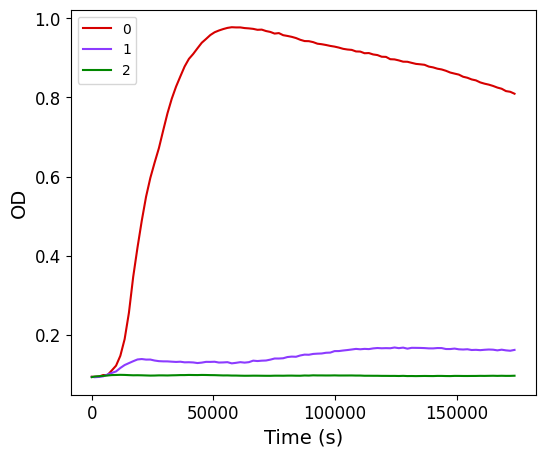

In [10]:
#Now lets see how is the generation using the Conditions
#The generation conditiones(strain and drug)
drug0=[1,0]  #Kanamycin [0-3.75 µg/mL], Mitomycin C [0-1.00 µg/mL] 
drug1=[2.50,0.5] 
drug2=[3.75,1.0] 
drug_amounts = pd.DataFrame([drug0,drug1,drug2])
strain1='WT'     #['WT', 'TolC', 'AcrD', 'AcrA', 'AcrB', 'AcrBD', 'AcrE', 'AcrF']
strain2='WT' 
strain3='WT'
strain1= binary_presence(strain1)
strain2= binary_presence(strain2)
strain3= binary_presence(strain3)
strains = pd.DataFrame([strain1,strain2,strain3])
C_tensor = torch.FloatTensor(pd.concat([strains,drug_amounts], axis=1).values) 
# print(C_tensor.shape)
# print(type(point))
# print(torch.FloatTensor(point).shape,torch.FloatTensor([point]).shape)
#Decoding the data using the trained autoencoder 
decoded_points= model(C_tensor).detach().numpy()

#Transpose it in order to plot 
decoded_points=pd.DataFrame(decoded_points).T
decoded_points['Time [s]'] = Time

fig, ax = plt.subplots(1,1,figsize=[6,5])

#Plot the decoded vectors
palette2=sns.color_palette(cc.glasbey,drug_amounts.shape[0])
for column, color in zip(decoded_points.columns.values[:drug_amounts.shape[0]],palette2):
    sns.lineplot(data=decoded_points, x='Time [s]', y=column, ax=ax, color=color, label=column)

plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('OD', fontsize=14)
ax.set_xticks(range(0, 175000, 50000))
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()